# Diluted exact-K + local current validation (`jj_corr_dilute`)

Validates `jj_corr_dilute_claude.cu` (FREE field): exact-K tp/sp + local s1,s2,s3, with **master-field
source-origin superposition** ($C(t)=G(t)+G(t-N_t/2)$) and **4-pattern spin$\times$e/o dilution**.

Checks:
1. exact `tp/sp` mean vs the zero-noise `corr_deter_exactsum_L1` (small $dt$, where the $N_t/2$ wrap is tiny);
2. local `s1,s2,s3` mean vs `corr_deter_local_L1`;  $s_1=s_2$ (free-field spin-diagonal block);
3. ratios $G_s/G_t\to-1$ (local: $(s_1{+}s_2)/2$ over $s_3$ -- exact deviates at coarse $L$ from the GW/resolvent dressing) -- **no $1/(D-1)$**;
4. **variance**: diluted (this) vs the volume run `corr_nt02_nhits64` at matched cost (1 diluted hit = 4 patterns $\approx$ 4 volume hits).

Errors = jackknife over hits. The dilute output is already superposed + 4-pattern-summed per hit (keys
`h0/{tp,sp,s1,s2,s3}/Vpp`, no `t0_*`); the deterministic refs are single-origin $G[dt]$.

**Four-fold folding.** The master-field $C(t)=G(t)+G(t-N_t/2)$ has period $N_t/2$ and reflection symmetry about $N_t/4$, so the 4 timeslices $\{dt,\,N_t/2{-}dt,\,N_t/2{+}dt,\,N_t{-}dt\}$ are averaged (`fourfold`), giving a noise-reduced estimate on $dt=0..N_t/4$. The single-origin determ/volume refs are put in the same master-field form (`mirror`: $G\to G+\mathrm{roll}(G,N_t/2)$) before folding, so all comparisons are like-for-like.

In [1]:
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt

In [2]:
# ----- config -----
dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ESN  = dir1 + 'data_free_vmRe0.000000vmIm0.000000/'
at_cft = 0.2; Nt_cft = 128; Delta_cft = 2.0
DIL = 'corr_dil_nt02_nhits64'        # <-- set to the nhits you ran (corr_dil_nt02_nhits<H>)
VOL = 'corr_nt02_nhits64'            # volume run (jj_corr_block_t) for the variance comparison
EXS = 'corr_deter_exactsum_L1'       # exact deterministic ground truth (single origin)
LOC = 'corr_deter_local_L1'          # local deterministic ground truth (single origin)

def cft_shape(t): return np.exp(-Delta_cft*t)*(1.0-np.exp(-t))**(-2.0*Delta_cft)

# ----- diluted loaders: per-hit files (keys h0/<proj>/Vpp, already superposed+pattern-summed) -----
def dil_files(dirn):
    out=[]
    for f in sorted(glob.glob(ESN+dirn+'/corr.0.h*.h5')):
        with h5py.File(f,'r') as h:
            if 'complete' in h: out.append(f)
    return out
def dil_hits(dirn, key):                 # key e.g. 'tp/Vpp','s1/Vpp' -> (nhits,Nt) complex
    out=[]
    for f in dil_files(dirn):
        with h5py.File(f,'r') as h:
            out.append(h['h0/'+key+'/real'][()] + 1j*h['h0/'+key+'/imag'][()])
    assert out, 'no complete diluted hits in %s (check DIL / that the run produced this dir)' % dirn
    return np.array(out)

# ----- volume loader (jj_corr_block_t): per-hit, keys h0/t0_<b>/<proj>/Vpp; average over t0 -----
def vol_hits(dirn, key):
    out=[]
    for f in sorted(glob.glob(ESN+dirn+'/corr.0.h*.h5')):
        with h5py.File(f,'r') as h:
            if 'complete' not in h: continue
            bs=[k for k in h['h0'] if k.startswith('t0_')]
            acc=None
            for b in bs:
                v=h['h0/'+b+'/'+key+'/real'][()]+1j*h['h0/'+b+'/'+key+'/imag'][()]
                acc=v if acc is None else acc+v
            out.append(acc/len(bs))
    return np.array(out)

def jk_mean_err(arr):                     # (nhits,Nt) -> (mean,err) over hits, real part
    a=arr.real; H=len(a); s=a.sum(0)
    samp=np.array([(s-a[i])/(H-1) for i in range(H)])
    est=samp.mean(0); var=(H-1)*np.mean((samp-est)**2,0)
    return est, np.sqrt(var)
def jk_ratio(num,den):                     # leave-one-out ratio of hit-sums -> (mean,err)
    n=num.real; d=den.real; H=len(n); sn=n.sum(0); sd=d.sum(0)
    samp=np.array([(sn-n[i])/(sd-d[i]) for i in range(H)])
    est=samp.mean(0); var=(H-1)*np.mean((samp-est)**2,0)
    return est, np.sqrt(var)

# ----- deterministic refs (single file, single origin t0_0) -----
def DET(corrdir, key):
    with h5py.File(ESN+corrdir+'/corr.0.h5','r') as f:
        return (f['h0/t0_0/'+key+'/Vpp/real'][()]+1j*f['h0/t0_0/'+key+'/Vpp/imag'][()]).real

# ----- FOUR-FOLD folding of the master-field (mirrored) correlator -----
# The superposed source gives C(t)=G(t)+G(t-Nt/2): period Nt/2 AND reflection-symmetric about Nt/4.
# Average the (up to) 4 equivalent timeslices {dt, Nt/2-dt, Nt/2+dt, Nt-dt} -> noise-reduced estimate on
# the folded domain dt=0..Nt/4.  fourfold(C(t)) = G(dt)+G(Nt/2-dt); the single-origin deterministic G(dt)
# is put in the SAME form via mirror() before folding, so folded diluted and folded determ compare directly.
def fourfold(C):
    Nt=len(C); h=Nt//2; q=Nt//4
    return np.array([np.mean([C[i] for i in sorted(set([d%Nt,(h-d)%Nt,(h+d)%Nt,(Nt-d)%Nt]))]) for d in range(q+1)])
def mirror(G):
    return G + np.roll(G, len(G)//2)                 # single-origin G(dt) -> master-field C(t)=G(t)+G(t-Nt/2)
def dil_hits_f(dirn,key):
    return np.array([fourfold(a) for a in dil_hits(dirn,key)])          # (nhits, Nt/4+1) complex, folded
def vol_hits_f(dirn,key):
    return np.array([fourfold(mirror(a)) for a in vol_hits(dirn,key)])  # volume put in the master-field form, folded
def twofold(G):                                      # single-origin G(dt): only reflection about Nt/2 ->
    Nt=len(G); return np.array([np.mean([G[d%Nt],G[(Nt-d)%Nt]]) for d in range(Nt//2+1)])  # avg G(dt),G(Nt-dt); dt=0..Nt/2
def vol_hits_2f(dirn,key):
    return np.array([twofold(a) for a in vol_hits(dirn,key)])           # volume folded by its OWN 2-fold symmetry
def DET_f(corrdir,key):
    return fourfold(mirror(DET(corrdir,key))).real                      # determ mirrored+folded
# folded CFT-shape reference (single-G shape mirrored+folded, for the tp/sp anchor plots)
_tt = np.arange(Nt_cft)*at_cft
_cs = np.zeros(Nt_cft); _cs[1:] = cft_shape(_tt[1:])
def cft_fold():
    return fourfold(mirror(_cs)).real

print('diluted hits in %s: %d' % (DIL, len(dil_files(DIL))))
print('volume  hits in %s: %d' % (VOL, len(glob.glob(ESN+VOL+'/corr.0.h*.h5'))))

diluted hits in corr_dil_nt02_nhits64: 14
volume  hits in corr_nt02_nhits64: 64


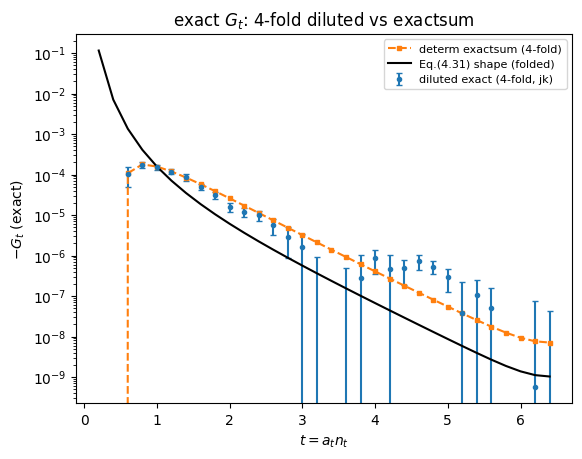

In [3]:
# EXACT G_t (tp): FOUR-FOLD-folded diluted (jk) vs exactsum vs CFT.  Master-field fold -> dt=0..Nt/4.  Re<0.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft; ref = 5
plt.figure()
m,e = jk_mean_err(dil_hits_f(DIL,'tp/Vpp'))
plt.errorbar(t, -m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted exact (4-fold, jk)')
anchor=-m[ref]
try:
    g=DET_f(EXS,'tp'); plt.plot(t,-g[dt],'s--',ms=3,label='determ exactsum (4-fold)'); anchor=-g[ref]
except (OSError,KeyError): print('exactsum not found')
csf=cft_fold(); plt.plot(t, (anchor/csf[ref])*csf[dt], 'k-', label='Eq.(4.31) shape (folded)')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$-G_t$ (exact)')
plt.title('exact $G_t$: 4-fold diluted vs exactsum'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_exact_tp.pdf', bbox_inches='tight')

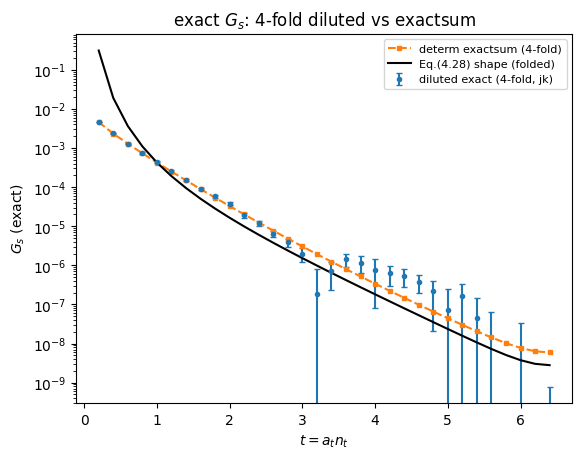

In [4]:
# EXACT G_s (sp): FOUR-FOLD-folded diluted (jk) vs exactsum vs CFT.  Re>0.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft; ref = 5
plt.figure()
m,e = jk_mean_err(dil_hits_f(DIL,'sp/Vpp'))
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted exact (4-fold, jk)')
anchor=m[ref]
try:
    g=DET_f(EXS,'sp'); plt.plot(t,g[dt],'s--',ms=3,label='determ exactsum (4-fold)'); anchor=g[ref]
except (OSError,KeyError): pass
csf=cft_fold(); plt.plot(t, (anchor/csf[ref])*csf[dt], 'k-', label='Eq.(4.28) shape (folded)')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$G_s$ (exact)')
plt.title('exact $G_s$: 4-fold diluted vs exactsum'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_exact_sp.pdf', bbox_inches='tight')

exact ratio @dt=5: -2.919 +- 0.363


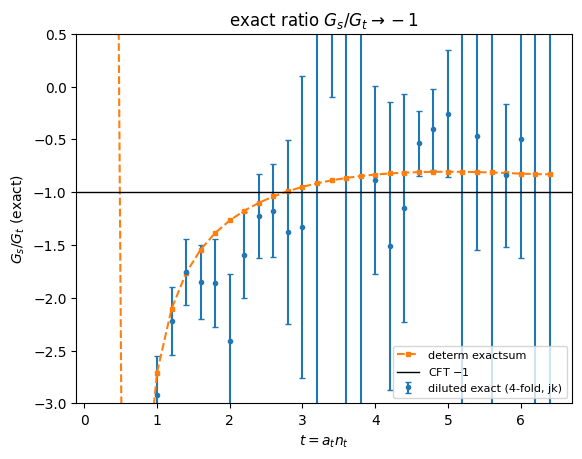

In [5]:
# EXACT ratio G_s/G_t -> -1 (v2-13; NO 1/(D-1)).  FOUR-FOLD-folded diluted (jk errorbar) vs exactsum.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft; ref = 5
plt.figure()
m,e = jk_ratio(dil_hits_f(DIL,'sp/Vpp'), dil_hits_f(DIL,'tp/Vpp'))
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted exact (4-fold, jk)')
try:
    r=DET_f(EXS,'sp')/DET_f(EXS,'tp'); plt.plot(t,r[dt],'s--',ms=3,label='determ exactsum')
except (OSError,KeyError): pass
plt.axhline(-1.0,color='k',lw=1,label=r'CFT $-1$')
plt.ylim(-3,0.5); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$G_s/G_t$ (exact)')
plt.title('exact ratio $G_s/G_t\\to-1$'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_exact_ratio.pdf', bbox_inches='tight')
print('exact ratio @dt=%d: % .3f +- %.3f'%(ref,m[ref],e[ref]))

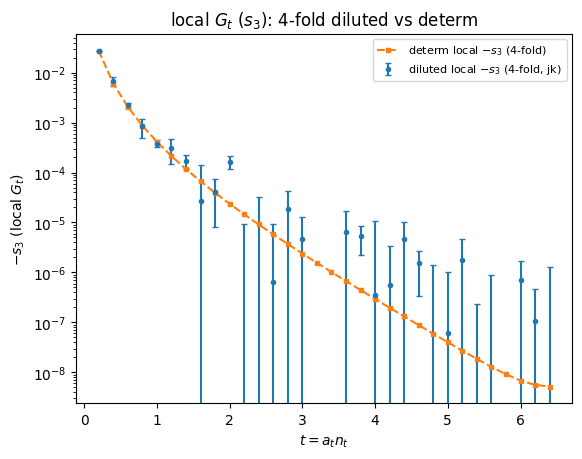

In [6]:
# LOCAL G_t (s3): FOUR-FOLD-folded diluted (jk) vs corr_deter_local.  Re<0.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft
plt.figure()
m,e = jk_mean_err(dil_hits_f(DIL,'s3/Vpp'))
plt.errorbar(t, -m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted local $-s_3$ (4-fold, jk)')
try:
    g=DET_f(LOC,'s3'); plt.plot(t,-g[dt],'s--',ms=3,label='determ local $-s_3$ (4-fold)')
except (OSError,KeyError): print('corr_deter_local not found')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$-s_3$ (local $G_t$)')
plt.title('local $G_t$ ($s_3$): 4-fold diluted vs determ'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_local_s3.pdf', bbox_inches='tight')

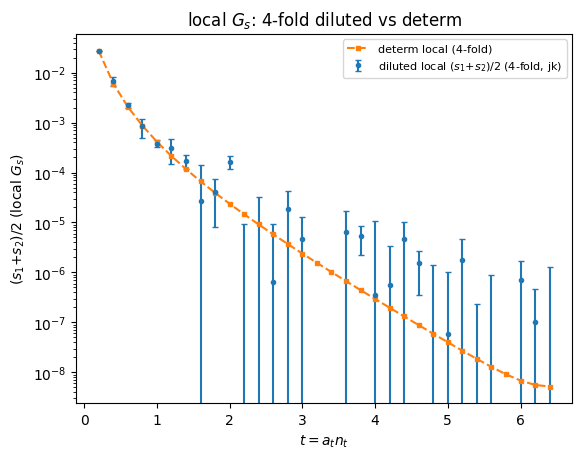

In [7]:
# LOCAL G_s = (s1+s2)/2: FOUR-FOLD-folded diluted (jk) vs corr_deter_local.  Re>0.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft
plt.figure()
gs = 0.5*(dil_hits_f(DIL,'s1/Vpp')+dil_hits_f(DIL,'s2/Vpp'))
m,e = jk_mean_err(gs)
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted local $(s_1{+}s_2)/2$ (4-fold, jk)')
try:
    g=0.5*(DET_f(LOC,'s1')+DET_f(LOC,'s2')); plt.plot(t,g[dt],'s--',ms=3,label='determ local (4-fold)')
except (OSError,KeyError): pass
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$(s_1{+}s_2)/2$ (local $G_s$)')
plt.title('local $G_s$: 4-fold diluted vs determ'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_local_sp.pdf', bbox_inches='tight')

local ratio @dt=5: -1.000 +- 0.000


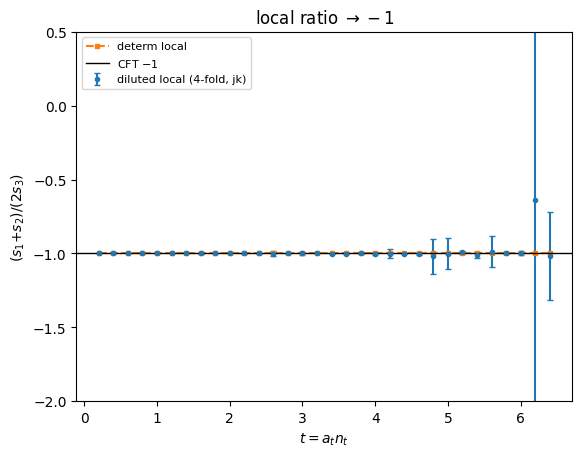

In [8]:
# LOCAL ratio (s1+s2)/2 / s3 -> -1.  FOUR-FOLD-folded diluted vs determ.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft; ref = 5
plt.figure()
m,e = jk_ratio(0.5*(dil_hits_f(DIL,'s1/Vpp')+dil_hits_f(DIL,'s2/Vpp')), dil_hits_f(DIL,'s3/Vpp'))
plt.errorbar(t, m[dt], yerr=e[dt], fmt='o', ms=3, capsize=2, label='diluted local (4-fold, jk)')
try:
    r=0.5*(DET_f(LOC,'s1')+DET_f(LOC,'s2'))/DET_f(LOC,'s3'); plt.plot(t,r[dt],'s--',ms=3,label='determ local')
except (OSError,KeyError): pass
plt.axhline(-1.0,color='k',lw=1,label=r'CFT $-1$')
plt.ylim(-2,0.5); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$(s_1{+}s_2)/(2 s_3)$')
plt.title(r'local ratio $\to-1$'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_local_ratio.pdf', bbox_inches='tight')
print('local ratio @dt=%d: % .3f +- %.3f'%(ref,m[ref],e[ref]))

max|s1-s2|/|s1| over dt: 8.461091192901307e-11


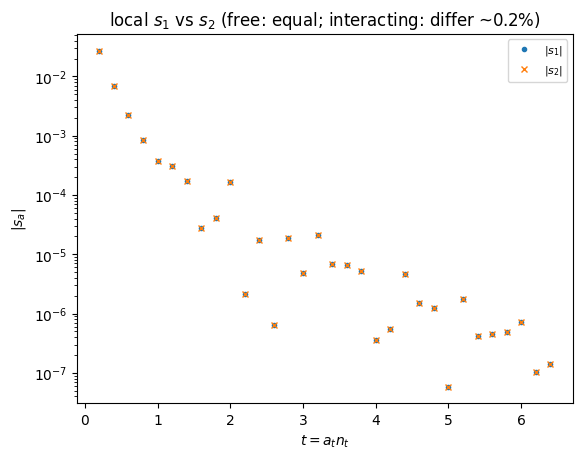

In [9]:
# LOCAL s1 vs s2 (free-field spin-diagonal same-site block => s1==s2).  FOUR-FOLD-folded.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft
m1,_=jk_mean_err(dil_hits_f(DIL,'s1/Vpp')); m2,_=jk_mean_err(dil_hits_f(DIL,'s2/Vpp'))
plt.figure()
plt.plot(t, np.abs(m1[dt]),'o',ms=3,label='$|s_1|$')
plt.plot(t, np.abs(m2[dt]),'x',ms=4,label='$|s_2|$')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$|s_a|$')
plt.title('local $s_1$ vs $s_2$ (free: equal; interacting: differ ~0.2%)'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_local_s1s2.pdf', bbox_inches='tight')
print('max|s1-s2|/|s1| over dt:', np.max(np.abs(m1[dt]-m2[dt])/np.abs(m1[dt])))

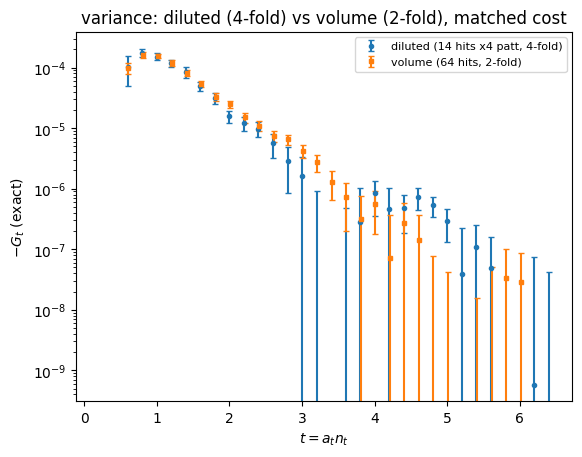

In [10]:
# VARIANCE: diluted vs volume (exact tp) at MATCHED COST (1 diluted hit = 4 patterns ~ 4 volume hits).
# The diluted master-field correlator is naturally FOUR-fold (period Nt/2 + reflect about Nt/4); the VOLUME
# run is single-origin G(dt), naturally TWO-fold (reflect about Nt/2 only).  Each is folded by ITS OWN
# symmetry, then the jackknife error bars on -G_t are compared on the common domain dt=1..Nt/4.
dt = np.arange(1, int(Nt_cft//4)+1); t = dt*at_cft
plt.figure()
md_,ed_ = jk_mean_err(dil_hits_f(DIL,'tp/Vpp'))
plt.errorbar(t, -md_[dt], yerr=ed_[dt], fmt='o', ms=3, capsize=2, label='diluted (%d hits x4 patt, 4-fold)'%len(dil_files(DIL)))
try:
    mv_,ev_ = jk_mean_err(vol_hits_2f(VOL,'tp/Vpp'))
    plt.errorbar(t+0.01, -mv_[dt], yerr=ev_[dt], fmt='s', ms=3, capsize=2, label='volume (%d hits, 2-fold)'%len(glob.glob(ESN+VOL+'/corr.0.h*.h5')))
except (OSError,KeyError): print('volume run not found')
plt.yscale('log'); plt.xlabel(r'$t=a_t n_t$'); plt.ylabel(r'$-G_t$ (exact)')
plt.title('variance: diluted (4-fold) vs volume (2-fold), matched cost'); plt.legend(fontsize=8)
plt.savefig('jj_dilute_variance.pdf', bbox_inches='tight')

In [11]:
# Summary table @dt=5 (FOUR-FOLD-folded).
ref=5
mt,et=jk_mean_err(dil_hits_f(DIL,'tp/Vpp')); ms,es=jk_mean_err(dil_hits_f(DIL,'sp/Vpp'))
mr,er=jk_ratio(dil_hits_f(DIL,'sp/Vpp'),dil_hits_f(DIL,'tp/Vpp'))
print('EXACT  @dt=%d:  G_t=% .3e +- %.1e   G_s=% .3e +- %.1e   G_s/G_t=% .3f +- %.3f'%(ref,mt[ref],et[ref],ms[ref],es[ref],mr[ref],er[ref]))
l3,_=jk_mean_err(dil_hits_f(DIL,'s3/Vpp')); lgs,_=jk_mean_err(0.5*(dil_hits_f(DIL,'s1/Vpp')+dil_hits_f(DIL,'s2/Vpp')))
lr,ler=jk_ratio(0.5*(dil_hits_f(DIL,'s1/Vpp')+dil_hits_f(DIL,'s2/Vpp')),dil_hits_f(DIL,'s3/Vpp'))
print('LOCAL  @dt=%d:  s3=% .3e   (s1+s2)/2=% .3e   ratio=% .3f +- %.3f'%(ref,l3[ref],lgs[ref],lr[ref],ler[ref]))
try:
    print('DETERM exactsum @dt=%d: G_t=% .3e G_s=% .3e ratio=% .3f'%(ref,DET_f(EXS,'tp')[ref],DET_f(EXS,'sp')[ref],(DET_f(EXS,'sp')/DET_f(EXS,'tp'))[ref]))
    print('DETERM local    @dt=%d: s3=% .3e (s1+s2)/2=% .3e ratio=% .3f'%(ref,DET_f(LOC,'s3')[ref],(0.5*(DET_f(LOC,'s1')+DET_f(LOC,'s2')))[ref],((0.5*(DET_f(LOC,'s1')+DET_f(LOC,'s2')))/DET_f(LOC,'s3'))[ref]))
except (OSError,KeyError): print('(a determ ref missing)')
print('CFT: G_t<0, G_s>0, ratio -> -1')

EXACT  @dt=5:  G_t=-1.523e-04 +- 2.0e-05   G_s= 4.442e-04 +- 2.1e-05   G_s/G_t=-2.919 +- 0.363
LOCAL  @dt=5:  s3=-3.794e-04   (s1+s2)/2= 3.794e-04   ratio=-1.000 +- 0.000
DETERM exactsum @dt=5: G_t=-1.573e-04 G_s= 4.260e-04 ratio=-2.709
DETERM local    @dt=5: s3=-4.130e-04 (s1+s2)/2= 4.130e-04 ratio=-1.000
CFT: G_t<0, G_s>0, ratio -> -1
